# code13 / lab13 — Predator-Prey Optimal Control with Pesticide

Python translation of `code13.m` + `lab13.m`.

`lab13.m` is interactive (it prompts for parameters with `input`). Here the parameters are passed directly in the last cell instead.

**Model** (scaled Lotka-Volterra with a pesticide control `u`):

$$\dot N_1 = (1 - N_2 - d_1 u)\,N_1,\qquad \dot N_2 = (N_1 - 1 - d_2 u)\,N_2,\qquad \dot z = u$$

- `N1` = prey / pest population, `N2` = predator population, `z` = cumulative pesticide used.
- `sweep()` solves the optimal control for a fixed costate constant `theta` via the forward-backward sweep (RK4).
- `code13()` wraps `sweep()` in a **secant method** that adjusts `theta` so the total pesticide `z(T)` hits the budget `B`.

> Note: the forward-backward sweep converges only for a short enough horizon `T`. For long horizons (e.g. T=20) the oscillatory predator-prey dynamics make the sweep fail to converge — that is a property of the method, not of this translation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def sweep(theta, A, d1, d2, M, N10, N20, T):
    test = -1.0
    delta = 0.001
    N = 1000
    t = np.linspace(0, T, N + 1)
    h = T / N
    h2 = h / 2.0

    N1 = np.zeros(N + 1); N2 = np.zeros(N + 1); z = np.zeros(N + 1)
    N1[0] = N10; N2[0] = N20

    lambda1 = np.zeros(N + 1); lambda1[N] = 1.0
    lambda2 = np.zeros(N + 1)
    lambda3 = np.zeros(N + 1) + theta
    u = np.zeros(N + 1)

    while test < 0:
        oldu, oldN1, oldN2, oldz = u.copy(), N1.copy(), N2.copy(), z.copy()
        oldl1, oldl2 = lambda1.copy(), lambda2.copy()

        # forward RK4 for the states
        for i in range(N):
            m11 = (1 - N2[i] - d1*u[i])*N1[i]
            m12 = (N1[i] - 1 - d2*u[i])*N2[i]
            m13 = u[i]

            m21 = (1 - (N2[i]+h2*m12) - d1*0.5*(u[i]+u[i+1]))*(N1[i]+h2*m11)
            m22 = ((N1[i]+h2*m11) - 1 - d2*0.5*(u[i]+u[i+1]))*(N2[i]+h2*m12)
            m23 = 0.5*(u[i]+u[i+1])

            m31 = (1 - (N2[i]+h2*m22) - d1*0.5*(u[i]+u[i+1]))*(N1[i]+h2*m21)
            m32 = ((N1[i]+h2*m21) - 1 - d2*0.5*(u[i]+u[i+1]))*(N2[i]+h2*m22)
            m33 = 0.5*(u[i]+u[i+1])

            m41 = (1 - (N2[i]+h*m32) - d1*u[i+1])*(N1[i]+h*m31)
            m42 = ((N1[i]+h*m31) - 1 - d2*u[i+1])*(N2[i]+h*m32)
            m43 = u[i+1]

            N1[i+1] = N1[i] + (h/6)*(m11 + 2*m21 + 2*m31 + m41)
            N2[i+1] = N2[i] + (h/6)*(m12 + 2*m22 + 2*m32 + m42)
            z[i+1]  = z[i]  + (h/6)*(m13 + 2*m23 + 2*m33 + m43)

        # backward RK4 for the adjoints
        for i in range(1, N + 1):
            j = N + 1 - i
            m11 = -lambda1[j]*(1 - N2[j] - d1*u[j]) - N2[j]*lambda2[j]
            m12 = -lambda2[j]*(N1[j] - 1 - d2*u[j]) + N1[j]*lambda1[j]

            m21 = -(lambda1[j]-h2*m11)*(1 - 0.5*(N2[j]+N2[j-1]) - d1*0.5*(u[j]+u[j-1])) - 0.5*(N2[j]+N2[j-1])*(lambda2[j]-h2*m12)
            m22 = -(lambda2[j]-h2*m12)*(0.5*(N1[j]+N1[j-1]) - 1 - d2*0.5*(u[j]+u[j-1])) + 0.5*(N1[j]+N1[j-1])*(lambda1[j]-h2*m11)

            m31 = -(lambda1[j]-h2*m21)*(1 - 0.5*(N2[j]+N2[j-1]) - d1*0.5*(u[j]+u[j-1])) - 0.5*(N2[j]+N2[j-1])*(lambda2[j]-h2*m22)
            m32 = -(lambda2[j]-h2*m22)*(0.5*(N1[j]+N1[j-1]) - 1 - d2*0.5*(u[j]+u[j-1])) + 0.5*(N1[j]+N1[j-1])*(lambda1[j]-h2*m21)

            m41 = -(lambda1[j]-h*m31)*(1 - N2[j-1] - d1*u[j-1]) - N2[j-1]*(lambda2[j]-h*m32)
            m42 = -(lambda2[j]-h*m32)*(N1[j-1] - 1 - d2*u[j-1]) + N1[j-1]*(lambda1[j]-h*m31)

            lambda1[j-1] = lambda1[j] - (h/6)*(m11 + 2*m21 + 2*m31 + m41)
            lambda2[j-1] = lambda2[j] - (h/6)*(m12 + 2*m22 + 2*m32 + m42)

        temp = (d1*N1*lambda1 + d2*N2*lambda2 - lambda3)/A
        u1 = np.minimum(M, np.maximum(0.0, temp))
        u = 0.5*(u1 + oldu)

        temp1 = delta*np.sum(np.abs(u)) - np.sum(np.abs(oldu - u))
        temp2 = delta*np.sum(np.abs(N1)) - np.sum(np.abs(oldN1 - N1))
        temp3 = delta*np.sum(np.abs(N2)) - np.sum(np.abs(oldN2 - N2))
        temp4 = delta*np.sum(np.abs(z)) - np.sum(np.abs(oldz - z))
        temp5 = delta*np.sum(np.abs(lambda1)) - np.sum(np.abs(oldl1 - lambda1))
        temp6 = delta*np.sum(np.abs(lambda2)) - np.sum(np.abs(oldl2 - lambda2))
        test = min(temp1, temp2, temp3, temp4, temp5, temp6)

    return np.vstack([t, N1, N2, u, z])

In [3]:
def code13(a, b, A, B, d1, d2, M, N10, N20, T):
    flag = -1
    z = sweep(a, A, d1, d2, M, N10, N20, T)
    Ta = z[4, 1000] - B
    print('1 iteration completed.')
    z = sweep(b, A, d1, d2, M, N10, N20, T)
    Tb = z[4, 1000] - B
    print('2 iterations completed.')

    n = 2
    while flag < 0:
        if abs(Ta) > abs(Tb):
            a, b = b, a
            Ta, Tb = Tb, Ta
        d = Ta*(b - a)/(Tb - Ta)
        b = a; Tb = Ta
        a = a - d
        z = sweep(a, A, d1, d2, M, N10, N20, T)
        Ta = z[4, 1000] - B
        if abs(Ta) < 1e-10:
            flag = 1
        else:
            n += 1
            print(f'{n} iterations completed.')
    print(f'Final guess was {a}.')
    return z

In [4]:
# Parameters (lab13.m would normally prompt for these interactively).
# Short horizon T so the sweep converges; B is a feasible pesticide budget.
# a, b are the two secant guesses for the costate constant theta.
params = dict(a=-0.5, b=0.0, A=1.0, B=1.0, d1=0.5, d2=0.5,
              M=1.0, N10=1.0, N20=1.0, T=5.0)
print('Parameters:', params)
y = code13(**params)

Parameters: {'a': -0.5, 'b': 0.0, 'A': 1.0, 'B': 1.0, 'd1': 0.5, 'd2': 0.5, 'M': 1.0, 'N10': 1.0, 'N20': 1.0, 'T': 5.0}
1 iteration completed.


2 iterations completed.
3 iterations completed.


4 iterations completed.
5 iterations completed.


6 iterations completed.
Final guess was -0.23237582142131266.


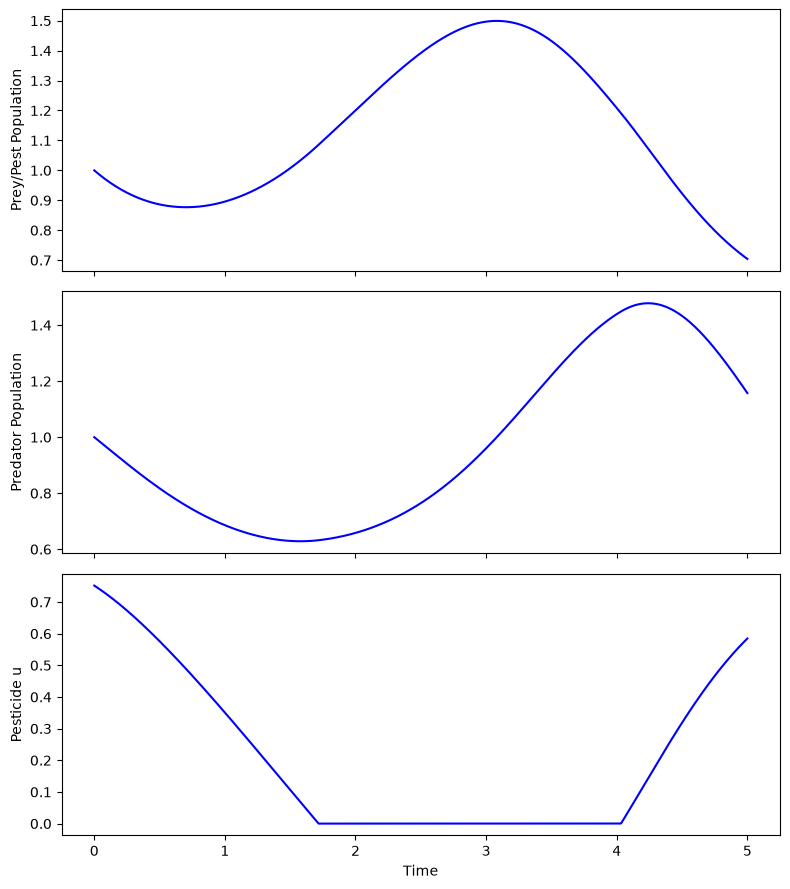

Final values at t=T:
  N1=0.704340  N2=1.157500  total pesticide z(T)=1.000000 (target B=1.0)
  u range: [0.000000, 0.751794]


In [5]:
t = y[0]
fig, ax = plt.subplots(3, 1, figsize=(8, 9), sharex=True)
ax[0].plot(t, y[1], 'b'); ax[0].set_ylabel('Prey/Pest Population')
ax[1].plot(t, y[2], 'b'); ax[1].set_ylabel('Predator Population')
ax[2].plot(t, y[3], 'b'); ax[2].set_ylabel('Pesticide u'); ax[2].set_xlabel('Time')
fig.tight_layout(); plt.show()

print('Final values at t=T:')
print(f'  N1={y[1,-1]:.6f}  N2={y[2,-1]:.6f}  total pesticide z(T)={y[4,-1]:.6f} (target B={params["B"]})')
print(f'  u range: [{y[3].min():.6f}, {y[3].max():.6f}]')